In [2]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Cloning repository
!git clone https://github.com/Haz1q1105/nlp-assignment3
%cd nlp-assignment3

# Install dependencies
!pip install sentencepiece matplotlib tqdm

Mounted at /content/drive
Cloning into 'nlp-assignment3'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 10 (delta 4), reused 8 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (10/10), 34.09 KiB | 17.05 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/nlp-assignment3


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import sentencepiece as spm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

In [6]:
!wget http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Electronics_5.json.gz

--2026-04-25 09:30:12--  http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Electronics_5.json.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 495854086 (473M) [application/x-gzip]
Saving to: ‘reviews_Electronics_5.json.gz’

reviews_Electronics 100%[===================>] 472.88M  96.2MB/s    in 5.2s    

2026-04-25 09:30:17 (90.2 MB/s) - ‘reviews_Electronics_5.json.gz’ saved [495854086/495854086]



In [7]:
!wget http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Books_5.json.gz

--2026-04-25 09:30:24--  http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Books_5.json.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3223678899 (3.0G) [application/x-gzip]
Saving to: ‘reviews_Books_5.json.gz’

reviews_Books_5.jso 100%[===================>]   3.00G  83.9MB/s    in 41s     

2026-04-25 09:31:05 (74.4 MB/s) - ‘reviews_Books_5.json.gz’ saved [3223678899/3223678899]



In [8]:
!wget http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Clothing_Shoes_and_Jewelry_5.json.gz

--2026-04-25 09:32:05--  http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Clothing_Shoes_and_Jewelry_5.json.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 47285200 (45M) [application/x-gzip]
Saving to: ‘reviews_Clothing_Shoes_and_Jewelry_5.json.gz’

reviews_Clothing_Sh 100%[===================>]  45.09M  38.3MB/s    in 1.2s    

2026-04-25 09:32:06 (38.3 MB/s) - ‘reviews_Clothing_Shoes_and_Jewelry_5.json.gz’ saved [47285200/47285200]



In [9]:
!ls -lh

total 3.6G
-rw-r--r-- 1 root root  57K Apr 25 09:29 i232579_NLP_Assignment3.ipynb
drwxr-xr-x 2 root root 4.0K Apr 25 09:30 models
drwxr-xr-x 2 root root 4.0K Apr 25 09:30 results
-rw-r--r-- 1 root root 3.1G Apr 26  2016 reviews_Books_5.json.gz
-rw-r--r-- 1 root root  46M Apr 26  2016 reviews_Clothing_Shoes_and_Jewelry_5.json.gz
-rw-r--r-- 1 root root 473M Apr 26  2016 reviews_Electronics_5.json.gz
-rw-r--r-- 1 root root    0 Apr 25 09:29 test.txt


In [10]:
import gzip
import json
from tqdm import tqdm

def load_category(file_path, max_samples=15000):
    data = []

    with gzip.open(file_path, 'rt', encoding='utf-8') as f:
        for i, line in enumerate(tqdm(f)):
            if i >= max_samples:
                break

            review = json.loads(line)

            # NOTE: same keys here
            if 'reviewText' in review and 'overall' in review:
                data.append((review['reviewText'], int(review['overall'])))

    return data

In [11]:
electronics = load_category("reviews_Electronics_5.json.gz")
books = load_category("reviews_Books_5.json.gz")
clothing = load_category("reviews_Clothing_Shoes_and_Jewelry_5.json.gz")

data = electronics + books + clothing

print("Total dataset size:", len(data))
print("Sample:", data[0])

15000it [00:00, 55919.63it/s]
15000it [00:00, 67542.36it/s]
15000it [00:00, 98544.51it/s] 

Total dataset size: 45000
Sample: ('We got this GPS for my husband who is an (OTR) over the road trucker.  Very Impressed with the shipping time, it arrived a few days earlier than expected...  within a week of use however it started freezing up... could of just been a glitch in that unit.  Worked great when it worked!  Will work great for the normal person as well but does have the "trucker" option. (the big truck routes - tells you when a scale is coming up ect...)  Love the bigger screen, the ease of use, the ease of putting addresses into memory.  Nothing really bad to say about the unit with the exception of it freezing which is probably one in a million and that\'s just my luck.  I contacted the seller and within minutes of my email I received a email back with instructions for an exchange! VERY impressed all the way around!', 5)


In [12]:
## splitting data for preparation for RAG

import random

random.shuffle(data)

train_size = int(0.7 * len(data))
val_size = int(0.15 * len(data))

train_data = data[:train_size]
val_data = data[train_size:train_size+val_size]
test_data = data[train_size+val_size:]

print(len(train_data), len(val_data), len(test_data))

31499 6750 6751


In [13]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    return text

In [14]:
from collections import Counter

counter = Counter()

for text, _ in train_data:
    tokens = clean_text(text).split()
    counter.update(tokens)

vocab_size = 8000

most_common = counter.most_common(vocab_size - 2)

vocab = {"<pad>": 0, "<unk>": 1}

for word, _ in most_common:
    vocab[word] = len(vocab)

print("Vocab size:", len(vocab))

Vocab size: 8000


In [15]:
MAX_LEN = 64

def encode(text):
    text = clean_text(text)
    tokens = text.split()

    ids = [vocab.get(t, 1) for t in tokens]  # 1 = <unk>
    ids = ids[:MAX_LEN]

    ids += [0] * (MAX_LEN - len(ids))  # padding

    return ids

In [16]:
def sentiment_label(r):
    if r <= 2: return 0
    elif r == 3: return 1
    else: return 2

def review_length_feature(text):
    return 0 if len(text.split()) < 50 else 1

In [17]:
sample = train_data[0][0]

print("Original:", sample)
print("Encoded:", encode(sample))
print("Length:", len(encode(sample)))

Original: My previous Skagen was a titanium one with a blue/purple face. Very sharp looking and it received many compliments. Unfortunately, after many years of use, the band gave out (though the actual mechanicals are still working...), so I needed to purchase a replacement.I did look at getting the same type, but opted for this version, as it was cheaper. And I wanted a change.Note: It's not as &#34;whilte&#34; as it appears in the picture (thankfully!). It's more of a silver color.Note: I also received mine already running, so not sure how long the battery will last. But that's an inexpensive fix.
Encoded: [17, 683, 4996, 20, 4, 7234, 28, 14, 4, 1, 710, 31, 1073, 197, 3, 9, 613, 96, 2523, 796, 90, 96, 103, 7, 77, 2, 471, 475, 54, 169, 2, 1046, 1, 18, 105, 435, 27, 6, 306, 5, 330, 4, 1, 119, 143, 30, 297, 2, 158, 495, 16, 4690, 12, 11, 418, 21, 9, 20, 881, 3, 6, 279, 4, 1]
Length: 64


In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [19]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0)/d_model))

        pe[:, 0::2] = torch.sin(pos * div_term)
        pe[:, 1::2] = torch.cos(pos * div_term)

        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

In [20]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, heads):
        super().__init__()

        self.heads = heads
        self.d_k = d_model // heads

        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)

        self.out = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, D = x.shape

        q = self.q(x).view(B, T, self.heads, self.d_k).transpose(1,2)
        k = self.k(x).view(B, T, self.heads, self.d_k).transpose(1,2)
        v = self.v(x).view(B, T, self.heads, self.d_k).transpose(1,2)

        scores = (q @ k.transpose(-2,-1)) / np.sqrt(self.d_k)
        attn = torch.softmax(scores, dim=-1)

        out = (attn @ v).transpose(1,2).contiguous().view(B, T, D)

        return self.out(out)

In [21]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, heads):
        super().__init__()

        self.attn = MultiHeadAttention(d_model, heads)
        self.norm1 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_model*4),
            nn.ReLU(),
            nn.Linear(d_model*4, d_model)
        )

        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        x = self.norm1(x + self.attn(x))
        x = self.norm2(x + self.ff(x))
        return x

In [22]:
class EncoderModel(nn.Module):
    def __init__(self, vocab_size, d_model=128, heads=4, layers=2):
        super().__init__()

        self.embed = nn.Embedding(vocab_size, d_model)
        self.pos = PositionalEncoding(d_model)

        self.layers = nn.ModuleList([
            EncoderBlock(d_model, heads) for _ in range(layers)
        ])

        # Outputs
        self.sentiment_head = nn.Linear(d_model, 3)
        self.feature_head = nn.Linear(d_model, 2)

    def forward(self, x):
        x = self.embed(x)
        x = self.pos(x)

        for layer in self.layers:
            x = layer(x)

        # pooling
        rep = x.mean(dim=1)

        sentiment = self.sentiment_head(rep)
        feature = self.feature_head(rep)

        return sentiment, feature, rep

In [23]:
def prepare_batch(batch):
    texts, ratings = zip(*batch)

    X = torch.tensor([encode(t) for t in texts]).to(device)
    y1 = torch.tensor([sentiment_label(r) for r in ratings]).to(device)
    y2 = torch.tensor([review_length_feature(t) for t in texts]).to(device)

    return X, y1, y2

In [48]:
model = EncoderModel(len(vocab)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

train_losses = []

for epoch in range(14):
    model.train()
    total_loss = 0

    for i in range(0, len(train_data), 64):
        batch = train_data[i:i+64]
        X, y1, y2 = prepare_batch(batch)

        s_pred, f_pred, _ = model(X)

        loss = F.cross_entropy(s_pred, y1) + F.cross_entropy(f_pred, y2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / (len(train_data)//64)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 0.6331
Epoch 2, Loss: 0.5647
Epoch 3, Loss: 0.5199
Epoch 4, Loss: 0.4847
Epoch 5, Loss: 0.4541
Epoch 6, Loss: 0.4259
Epoch 7, Loss: 0.3974
Epoch 8, Loss: 0.3633
Epoch 9, Loss: 0.3255
Epoch 10, Loss: 0.2834
Epoch 11, Loss: 0.2452
Epoch 12, Loss: 0.2276
Epoch 13, Loss: 0.2031
Epoch 14, Loss: 0.1601


In [49]:
import numpy as np

model.eval()

train_embeddings = []
train_texts = []

with torch.no_grad():
    for i in range(0, len(train_data), 64):
        batch = train_data[i:i+64]
        X, _, _ = prepare_batch(batch)

        _, _, rep = model(X)

        train_embeddings.append(rep.cpu().numpy())
        train_texts.extend([t for t, _ in batch])

train_embeddings = np.vstack(train_embeddings)

print("Embeddings shape:", train_embeddings.shape)

Embeddings shape: (31499, 128)


In [50]:
np.save("train_embeddings.npy", train_embeddings)

In [51]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)

In [52]:
def retrieve(query_text, k=3):
    model.eval()

    X = torch.tensor([encode(query_text)]).to(device)

    with torch.no_grad():
        _, _, query_vec = model(X)

    query_vec = query_vec.cpu().numpy().squeeze()

    sims = np.dot(train_embeddings, query_vec)

    top_k_idx = np.argsort(sims)[-k:][::-1]

    return [train_texts[i] for i in top_k_idx]

In [53]:
query = "This product is amazing and works perfectly"

results = retrieve(query, k=3)

print("Query:", query)
print("\nTop Matches:\n")

for i, r in enumerate(results):
    print(f"{i+1}. {r}\n")

Query: This product is amazing and works perfectly

Top Matches:

1. Excellent cable for computer and printer.

2. perfect!

3. They look great and give great support.  I love them.



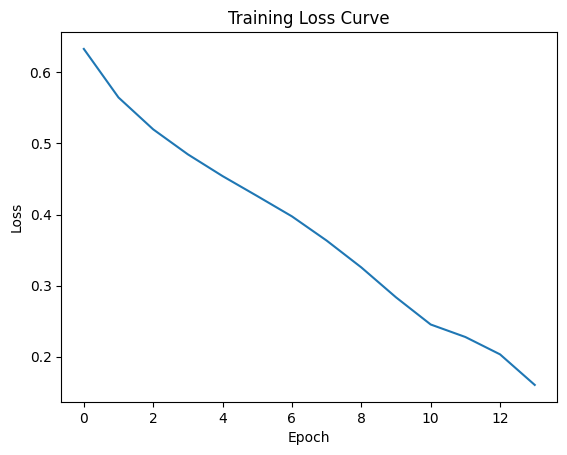

In [54]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [55]:
def build_explanation(text, sentiment, feature):
    sentiment_map = ["negative", "neutral", "positive"]
    length_map = ["short", "long"]

    return f"This review is {sentiment_map[sentiment]} because it is a {length_map[feature]} review."

In [56]:
decoder_data = []

for text, rating in train_data[:20000]:  # limit for speed
    sent = sentiment_label(rating)
    feat = review_length_feature(text)

    explanation = build_explanation(text, sent, feat)

    inp = encode(text)
    tgt = encode(explanation)

    decoder_data.append((inp, tgt))

In [57]:
class MaskedMultiHeadAttention(nn.Module):
    def __init__(self, d_model, heads):
        super().__init__()

        self.heads = heads
        self.d_k = d_model // heads

        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)

        self.out = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, D = x.shape

        q = self.q(x).view(B, T, self.heads, self.d_k).transpose(1,2)
        k = self.k(x).view(B, T, self.heads, self.d_k).transpose(1,2)
        v = self.v(x).view(B, T, self.heads, self.d_k).transpose(1,2)

        scores = (q @ k.transpose(-2,-1)) / np.sqrt(self.d_k)

        # CAUSAL MASK
        mask = torch.tril(torch.ones(T, T)).to(x.device)
        scores = scores.masked_fill(mask == 0, -1e9)

        attn = torch.softmax(scores, dim=-1)

        out = (attn @ v).transpose(1,2).contiguous().view(B, T, D)

        return self.out(out)

In [58]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model, heads):
        super().__init__()

        self.attn = MaskedMultiHeadAttention(d_model, heads)
        self.norm1 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_model*4),
            nn.ReLU(),
            nn.Linear(d_model*4, d_model)
        )

        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        x = self.norm1(x + self.attn(x))
        x = self.norm2(x + self.ff(x))
        return x

In [59]:
class DecoderModel(nn.Module):
    def __init__(self, vocab_size, d_model=128, heads=4, layers=2):
        super().__init__()

        self.embed = nn.Embedding(vocab_size, d_model)
        self.pos = PositionalEncoding(d_model)

        self.layers = nn.ModuleList([
            DecoderBlock(d_model, heads) for _ in range(layers)
        ])

        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        x = self.embed(x)
        x = self.pos(x)

        for layer in self.layers:
            x = layer(x)

        return self.fc(x)

In [60]:
def predict_features(text):
    model.eval()

    X = torch.tensor([encode(text)]).to(device)

    with torch.no_grad():
        s_pred, f_pred, _ = model(X)

    sentiment = torch.argmax(s_pred, dim=1).item()
    feature = torch.argmax(f_pred, dim=1).item()

    return sentiment, feature

In [61]:
def build_rag_input(text):
    sentiment, feature = predict_features(text)

    retrieved = retrieve(text, k=2)

    sentiment_map = ["negative", "neutral", "positive"]
    length_map = ["short", "long"]

    rag_text = f"""
    Review: {text}
    Sentiment: {sentiment_map[sentiment]}
    Length: {length_map[feature]}
    Similar Reviews: {retrieved[0]} || {retrieved[1]}
    Explanation:
    """

    return rag_text

In [66]:
def generate(decoder, prompt, max_len=40):
    decoder.eval()
    tokens = encode(prompt)

    for _ in range(max_len):
        X = torch.tensor([tokens]).to(device)

        with torch.no_grad():
            out = decoder(X)

        next_token = torch.argmax(out[0, -1]).item()

        tokens.append(next_token)
        tokens = tokens[-64:]

    return tokens

In [63]:
inv_vocab = {v:k for k,v in vocab.items()}

def decode_tokens(tokens):
    words = [inv_vocab.get(t, "<unk>") for t in tokens]
    return " ".join(words)